In [77]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
from faker import Faker
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

In [78]:
# --- Load ZIP Code Mapping ---
def load_zip_mapping(filepath='../data/zip_data_prefix_mapping.csv'):
    zip_mapping = pd.read_csv(filepath)
    return dict(zip(zip_mapping['zip_prefix'], zip_mapping['addr_state_actual']))

In [79]:
# --- Data Preprocessing ---
def load_and_preprocess_data(filepath):
    data = pd.read_csv(filepath)
    data.fillna(data.median(numeric_only=True), inplace=True)
    data.fillna(0, inplace=True)
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in data.select_dtypes(include=[np.number]).columns:
        data[col] = data[col].clip(lower=-1e10, upper=1e10)
    data.fillna(data.median(numeric_only=True), inplace=True)
    return data

In [80]:
# --- Fraud Detection Functions ---
def detect_geo_fraud(data, zip_mapping):
    if 'geo_fraud' not in data.columns:
        data['geo_fraud'] = 0
    state_cols = [col for col in data.columns if 'addr_state_' in col]
    if state_cols and 'zip_code' in data.columns:
        for index, row in data.iterrows():
            zip_prefix = int(str(row['zip_code'])[:3]) if str(row['zip_code'])[:3].isdigit() else -1
            expected_state = zip_mapping.get(zip_prefix, 'Unknown')
            if expected_state != 'Unknown':
                active_state = next((col.split('_')[-1] for col in state_cols if row[col] == 1), None)
                if active_state and active_state != expected_state:
                    data.at[index, 'geo_fraud'] = 1
    return data

In [81]:
def detect_loan_stacking(data):
    # Use the correct column names
    required_cols = ['loan_amnt', 'annual_inc', 'dti']
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns for loan stacking detection: {missing_cols}")
    duplicate_mask = data.duplicated(subset=['loan_amnt', 'annual_inc', 'dti'], keep=False)
    data['loan_stacking_fraud'] = duplicate_mask.astype(int)
    return data

In [82]:
def detect_dti_fraud(data):
    # Use the correct column names
    required_cols = ['dti', 'loan_amnt', 'annual_inc']
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns for DTI fraud detection: {missing_cols}")
    data['adjusted_dti'] = (data['dti'] + (data['loan_amnt'] / data['annual_inc'].replace(0, 1e-10))) * 100
    data['adjusted_dti'] = data['adjusted_dti'].clip(upper=1e10)
    data['dti_fraud'] = data['adjusted_dti'].apply(lambda x: 1 if x > 50 else 0)
    data['dti_high_risk'] = data['adjusted_dti'].apply(lambda x: 1 if 43 <= x <= 50 else 0)
    return data

In [83]:
# --- Isolation Forest for Base Model ---
def apply_isolation_forest(data, contamination=0.02):
    numeric_data = data.select_dtypes(include=[np.number])
    iso_forest = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    data['iso_fraud'] = iso_forest.fit_predict(numeric_data)
    data['iso_fraud'] = data['iso_fraud'].apply(lambda x: 1 if x == -1 else 0)
    return data, iso_forest

In [84]:
# --- Generate Synthetic Fraud Data ---
def generate_synthetic_fraud_data(real_data, n_samples, zip_mapping=None):
    if zip_mapping is None:
        zip_mapping = load_zip_mapping()
    
    fake = Faker()
    state_cols = [col for col in real_data.columns if 'addr_state_' in col]
    states = [col.split('_')[-1] for col in state_cols]
    job_cols = [col for col in real_data.columns if 'job_category_' in col]
    zip_prefixes = list(zip_mapping.keys())

    # Update column names to match the dataset
    numeric_cols = ['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'emp_length', 
                    'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 
                    'revol_bal', 'revol_util', 'total_acc', 'total_pymnt', 'total_rec_prncp', 
                    'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 
                    'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'mort_acc', 
                    'credit_age_years', 'issue_year']

    fraud_data = {
        'zip_code': [str(np.random.choice(zip_prefixes)) + str(fake.random_number(digits=2)).zfill(2) for _ in range(n_samples)],
    }
    fraud_zip_prefixes = [int(z[:3]) for z in fraud_data['zip_code']]
    fraud_states = [np.random.choice([s for s in states if s != zip_mapping.get(p, 'Unknown')]) for p in fraud_zip_prefixes]
    
    for col in numeric_cols:
        if col in real_data.columns:
            min_val, max_val = real_data[col].min(), real_data[col].max()
            if col == 'dti':
                fraud_data[col] = np.random.uniform(0, 0.4, n_samples)
            elif col == 'loan_amnt':
                fraud_data[col] = np.random.uniform(min_val, max_val, n_samples)
            elif col == 'annual_inc':
                fraud_data[col] = np.random.uniform(max(1e-10, min_val), max_val, n_samples)
            elif col in ['term']:
                fraud_data[col] = np.random.choice([36, 60], n_samples)
            elif col in ['emp_length', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 
                         'total_acc', 'last_pymnt_d', 'last_credit_pull_d', 'mort_acc', 'issue_year']:
                fraud_data[col] = np.random.randint(int(min_val), int(max_val) + 1, n_samples)
            else:
                fraud_data[col] = np.random.uniform(min_val, max_val, n_samples)
    
    for i in range(n_samples):
        base_dti = fraud_data['dti'][i]
        loan_amnt = fraud_data['loan_amnt'][i]
        annual_inc = fraud_data['annual_inc'][i]
        adjusted_dti = (base_dti + (loan_amnt / annual_inc)) * 100
        if adjusted_dti <= 43:
            target_dti = np.random.uniform(44, 1000)
            annual_inc = loan_amnt / ((target_dti / 100) - base_dti)
            fraud_data['annual_inc'][i] = max(min(annual_inc, 1e10), real_data['annual_inc'].min())
    
    n_stacking = int(n_samples * 0.3)
    stacking_indices = np.random.choice(n_samples, n_stacking, replace=False)
    for idx in stacking_indices:
        duplicate_idx = np.random.randint(0, n_samples)
        fraud_data['loan_amnt'][idx] = fraud_data['loan_amnt'][duplicate_idx]
        fraud_data['annual_inc'][idx] = fraud_data['annual_inc'][duplicate_idx]
        fraud_data['dti'][idx] = fraud_data['dti'][duplicate_idx]
    
    for state in states:
        fraud_data[f'addr_state_{state}'] = (np.array(fraud_states) == state).astype(int)
    for job_col in job_cols:
        fraud_data[job_col] = (np.random.choice(job_cols, n_samples) == job_col).astype(int)

    data = pd.DataFrame(fraud_data)
    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    
    data = detect_loan_stacking(data)
    data = detect_geo_fraud(data, zip_mapping)
    data = detect_dti_fraud(data)
    return data

In [85]:
# --- Feature Engineering ---
def add_features(data, zip_mapping):
   
    # Geo Mismatch Feature (instead of geo_fraud)
    data['geo_mismatch'] = 0
    state_cols = [col for col in data.columns if 'addr_state_' in col]
    if state_cols and 'zip_code' in data.columns:
        for index, row in data.iterrows():
            zip_prefix = int(str(row['zip_code'])[:3]) if str(row['zip_code'])[:3].isdigit() else -1
            expected_state = zip_mapping.get(zip_prefix, 'Unknown')
            if expected_state != 'Unknown':
                active_state = next((col.split('_')[-1] for col in state_cols if row[col] == 1), None)
                if active_state and active_state != expected_state:
                    data.at[index, 'geo_mismatch'] = 1
    
    # Loan Stacking Count (instead of loan_stacking_fraud)
    required_cols = ['loan_amnt', 'annual_inc', 'dti']
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns for feature engineering: {missing_cols}")
    # Corrected: Use transform to count occurrences in each group
    data['loan_stacking_count'] = data.groupby(['loan_amnt', 'annual_inc', 'dti'])['loan_amnt'].transform('count')
    
    # Interaction Features
    data['loan_to_income'] = data['loan_amnt'] / data['annual_inc'].replace(0, 1e-10)
    data['dti_revol_util'] = data['dti'] * data.get('revol_util', 0)  # Use .get() to handle missing revol_util
    
    return data

In [86]:
# --- Prepare Data for Training ---
def prepare_data_for_training(data, reference_columns=None):
    y = data['fraud_prediction']
    # Exclude fraud-related features to prevent data leakage
    exclude_cols = ['fraud_prediction', 'geo_fraud', 'loan_stacking_fraud', 'dti_fraud', 'iso_fraud', 'dti_high_risk', 'adjusted_dti']
    X = data.select_dtypes(include=[np.number]).drop(columns=exclude_cols, errors='ignore')
    
    # Align columns with reference_columns (if provided)
    if reference_columns is not None:
        missing_cols = [col for col in reference_columns if col not in X.columns]
        for col in missing_cols:
            X[col] = 0
        X = X[reference_columns]  # Reorder columns to match reference
        
    print(f"Features before scaling: {list(X.columns)}")
    print(f"Number of features: {len(X.columns)}")
    
    if y.isna().any():
        print(f"Warning: {y.isna().sum()} NaN values in fraud_prediction. Dropping these rows.")
        valid_mask = ~y.isna()
        X = X[valid_mask]
        y = y[valid_mask]
    
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in X.columns:
        X[col] = X[col].clip(lower=-1e10, upper=1e10)
    nan_cols = X.columns[X.isna().any()].tolist()
    if nan_cols:
        print("Columns with NaN in X:", nan_cols)
        print("NaN counts per column:\n", X.isna().sum())
        X.fillna(X.median(), inplace=True)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    joblib.dump(scaler, '../models/scaler_refactored.pkl')
    return X_scaled, y, scaler

In [87]:
# --- Define Neural Network Model (Deeper Architecture) ---
class FraudDetectionModel(nn.Module):
    def __init__(self, input_size):
        super(FraudDetectionModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.network(x)

In [88]:
# --- Train Model ---
def train_model(X_train, y_train, X_test, y_test, input_size, epochs=50, lr=0.001):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    model = FraudDetectionModel(input_size)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                test_outputs = model(X_test_tensor)
                test_preds = (torch.sigmoid(test_outputs) > 0.5).float()
                print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Fraud Cases: {test_preds.sum().item()}")

    return model

In [89]:
# --- Evaluate Model ---
def evaluate_model(model, X_test, y_test, threshold=0.5):
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    with torch.no_grad():
        y_pred_proba = torch.sigmoid(model(X_test_tensor)).numpy()
        y_pred = (y_pred_proba > threshold).astype(int)
    
    print(f"Classification Report (Threshold={threshold}):")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    print(f"Precision-Recall AUC: {pr_auc:.4f}")
    return y_pred

In [90]:
# --- Check Data Balance ---
def check_data_balance(data):
    fraud_count = data['fraud_prediction'].sum()
    non_fraud_count = len(data) - fraud_count
    total_count = len(data)
    fraud_percentage = (fraud_count / total_count) * 100
    non_fraud_percentage = (non_fraud_count / total_count) * 100
    
    print("\nDataset Balance After Implementing Synthetic Fraud:")
    print(f"Total Rows: {total_count}")
    print(f"Fraud Cases (1): {fraud_count} ({fraud_percentage:.2f}%)")
    print(f"Non-Fraud Cases (0): {non_fraud_count} ({non_fraud_percentage:.2f}%)")
    
    # Bar Chart
    plt.figure(figsize=(8, 5))
    sns.barplot(x=['Non-Fraud', 'Fraud'], y=[non_fraud_count, fraud_count], hue=['Non-Fraud', 'Fraud'], palette='viridis', legend=False)
    plt.title('Fraud vs. Non-Fraud Distribution')
    plt.ylabel('Count')
    for i, v in enumerate([non_fraud_count, fraud_count]):
        plt.text(i, v + 5000, str(v), ha='center', va='bottom')
    plt.show()
    
    # Pie Chart
    plt.figure(figsize=(8, 5))
    plt.pie([non_fraud_count, fraud_count], labels=['Non-Fraud', 'Fraud'], autopct='%1.2f%%', colors=sns.color_palette('viridis', 2))
    plt.title('Fraud vs. Non-Fraud Proportion')
    plt.show()


In [91]:
# Cell 1: Define Helper Functions (Assuming these are already defined elsewhere)
# Functions like load_zip_mapping, load_and_preprocess_data, detect_loan_stacking, 
# detect_geo_fraud, detect_dti_fraud, apply_isolation_forest, add_features, 
# prepare_data_for_training, train_model, evaluate_model, check_data_balance, 
# generate_synthetic_fraud_data are assumed to be defined.

# Cell 2: Define Modular Functions

def load_and_prepare_data(data_path):
    """Load and preprocess the data, apply fraud detection, and add features."""
    print("Starting fraud detection process...")
    zip_mapping = load_zip_mapping()
    data = load_and_preprocess_data(data_path)
    
    # Apply fraud detection functions to real data
    data = detect_loan_stacking(data)
    data = detect_geo_fraud(data, zip_mapping)
    data = detect_dti_fraud(data)
    data, iso_forest = apply_isolation_forest(data, contamination=0.02)
    
    # Create fraud prediction column
    data['fraud_prediction'] = ((data['iso_fraud'] == 1) | 
                               (data['geo_fraud'] == 1) | 
                               (data['loan_stacking_fraud'] == 1) | 
                               (data['dti_fraud'] == 1)).astype(int)
    
    # Add new features to real data
    data = add_features(data, zip_mapping)
    
    return data, zip_mapping, iso_forest



In [92]:
def sprint2_us002_train_baseline(data):
    """Sprint 2 - US002: Train and evaluate the baseline model on real data."""
    # Split real data into train and holdout
    real_data = data.copy()
    real_train, real_holdout = train_test_split(real_data, test_size=0.2, stratify=real_data['fraud_prediction'], random_state=42)
    
    # Train baseline model
    print("\nSprint 2 - US002: Training Baseline Model on Real Data...")
    X_train, y_train, scaler_baseline = prepare_data_for_training(real_train)
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    baseline_model = train_model(X_train_split, y_train_split, X_val_split, y_val_split, X_train_split.shape[1])
    
    # Evaluate baseline model on real holdout set
    reference_columns_baseline = real_train.select_dtypes(include=[np.number]).drop(columns=['fraud_prediction', 'geo_fraud', 'loan_stacking_fraud', 'dti_fraud', 'iso_fraud', 'dti_high_risk', 'adjusted_dti'], errors='ignore').columns.tolist()
    X_holdout, y_holdout, _ = prepare_data_for_training(real_holdout, reference_columns=reference_columns_baseline)
    print("\nBaseline Model Performance (Sprint 2 - US002):")
    y_pred_baseline = evaluate_model(baseline_model, X_holdout, y_holdout, threshold=0.5)
    y_pred_proba_baseline = baseline_model(torch.FloatTensor(X_holdout)).detach().numpy().flatten()
    precision, recall, _ = precision_recall_curve(y_holdout, y_pred_proba_baseline)
    pr_auc_baseline = auc(recall, precision)
    print(f"Accuracy: {accuracy_score(y_holdout, y_pred_baseline):.4f}")
    print(f"Precision-Recall AUC: {pr_auc_baseline:.4f}")
    print("Classification Report:")
    print(classification_report(y_holdout, y_pred_baseline, target_names=['Non-Fraud', 'Fraud']))
    
    return real_train, real_holdout, baseline_model, y_pred_baseline, reference_columns_baseline



In [93]:
def sprint2_us003_loan_stacking(data, real_holdout, y_pred_baseline):
    """Sprint 2 - US003: Loan stacking fraud detection and verification."""
    print("\nSprint 2 - US003: Loan Stacking Fraud Detection Results...")
    total_apps = len(data)
    stacking_fraud_apps = len(data[data['loan_stacking_fraud'] == 1])
    print(f"Total Applications in Real Data: {total_apps}")
    print(f"Applications Flagged as Loan Stacking Fraud: {stacking_fraud_apps} ({stacking_fraud_apps / total_apps * 100:.2f}%)")
    
    # Visualize loan stacking fraud distribution
    plt.figure(figsize=(8, 5))
    plt.bar(['Non-Stacking', 'Stacking'], [total_apps - stacking_fraud_apps, stacking_fraud_apps], color=['skyblue', 'salmon'])
    plt.title('Loan Stacking Fraud Distribution in Real Data (Sprint 2 - US003)')
    plt.ylabel('Number of Applications')
    for i, v in enumerate([total_apps - stacking_fraud_apps, stacking_fraud_apps]):
        plt.text(i, v + 10000, str(v), ha='center', va='bottom')
    plt.savefig('../images/loan_stacking_distribution.png')
    plt.show()
    
    # Preliminary verification with baseline model
    print("\nPreliminary Verification with Baseline Model (Sprint 2 - US003):")
    stacking_accuracy = accuracy_score(real_holdout['loan_stacking_fraud'], y_pred_baseline)
    print(f"Accuracy of baseline model predictions vs. loan_stacking_fraud labels: {stacking_accuracy:.4f}")
    print("Classification Report for loan stacking fraud detection:")
    print(classification_report(real_holdout['loan_stacking_fraud'], y_pred_baseline, target_names=['Non-Stacking', 'Stacking']))



In [94]:
def sprint2_us004_synthetic_data(real_train, zip_mapping):
    """Sprint 2 - US004: Generate synthetic fraud data and visualize results."""
    # Balance the training data with synthetic data
    non_fraud_count = (real_train['fraud_prediction'] == 0).sum()
    fraud_count = (real_train['fraud_prediction'] == 1).sum()
    n_synthetic_needed = non_fraud_count - fraud_count
    
    if n_synthetic_needed > 0:
        print("\nSprint 2 - US004: Generating Synthetic Fraud Data...")
        synthetic_data = generate_synthetic_fraud_data(real_train, n_samples=n_synthetic_needed, zip_mapping=zip_mapping)
        synthetic_data = add_features(synthetic_data, zip_mapping)
        
        # Synthetic fraud data statistics
        print("\nSynthetic Fraud Data Generation Results (Sprint 2 - US004):")
        print(f"Total Synthetic Samples Generated: {len(synthetic_data)}")
        stacking_fraud_synthetic = len(synthetic_data[synthetic_data['loan_stacking_fraud'] == 1])
        geo_fraud_synthetic = len(synthetic_data[synthetic_data['geo_fraud'] == 1])
        dti_fraud_synthetic = len(synthetic_data[synthetic_data['dti_fraud'] == 1])
        print(f"- Loan Stacking Fraud: {stacking_fraud_synthetic} ({stacking_fraud_synthetic / len(synthetic_data) * 100:.2f}%)")
        print(f"- Geographical Fraud: {geo_fraud_synthetic} ({geo_fraud_synthetic / len(synthetic_data) * 100:.2f}%)")
        print(f"- DTI Fraud: {dti_fraud_synthetic} ({dti_fraud_synthetic / len(synthetic_data) * 100:.2f}%)")
        print("New Fields Included in Synthetic Data:")
        new_fields = ['revol_bal', 'revol_util', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'mort_acc', 'credit_age_years']
        print(f"- {', '.join(new_fields)}")
        
        # Visualize synthetic fraud data breakdown
        plt.figure(figsize=(8, 5))
        plt.bar(['Loan Stacking Fraud', 'Geographical Fraud', 'DTI Fraud'], 
                [stacking_fraud_synthetic, geo_fraud_synthetic, dti_fraud_synthetic], 
                color=['salmon', 'lightgreen', 'lightblue'])
        plt.title('Breakdown of Fraud Types in Synthetic Data (Sprint 2 - US004)')
        plt.ylabel('Number of Synthetic Samples')
        for i, v in enumerate([stacking_fraud_synthetic, geo_fraud_synthetic, dti_fraud_synthetic]):
            plt.text(i, v + 10000, str(v), ha='center', va='bottom')
        plt.savefig('../images/synthetic_fraud_breakdown.png')
        plt.show()
        
        train_data = pd.concat([real_train, synthetic_data], ignore_index=True)
    else:
        train_data = real_train.copy()
    
    # Update fraud prediction for train_data
    train_data['fraud_prediction'] = ((train_data['geo_fraud'] == 1) | 
                                     (train_data['loan_stacking_fraud'] == 1) | 
                                     (train_data['dti_fraud'] == 1) | 
                                     (train_data.get('iso_fraud', 0) == 1)).astype(int)
    
    return train_data



In [95]:
def sprint3_us005_check_balance(train_data):
    """Sprint 3 - US005: Check dataset balance after adding synthetic data."""
    print("\nSprint 3 - US005: Dataset Balance After Implementing Synthetic Fraud:")
    check_data_balance(train_data)



In [96]:
def sprint3_us006_train_retrained(train_data, real_holdout, zip_mapping):
    """Sprint 3 - US006: Train and evaluate the retrained model on combined data."""
    # Define reference columns based on train_data (real + synthetic) to ensure consistency
    reference_columns = train_data.select_dtypes(include=[np.number]).drop(columns=['fraud_prediction', 'geo_fraud', 'loan_stacking_fraud', 'dti_fraud', 'iso_fraud', 'dti_high_risk', 'adjusted_dti'], errors='ignore').columns.tolist()
    
    # Train on balanced data (real + synthetic)
    print("\nSprint 3 - US006: Training Retrained Model with Combined Data...")
    X_scaled, y, scaler = prepare_data_for_training(train_data, reference_columns=reference_columns)
    X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
    
    model = train_model(X_train, y_train, X_val, y_val, X_train.shape[1])
    
    # Add features to holdout set
    real_holdout = add_features(real_holdout, zip_mapping)
    
    # Evaluate on real holdout set
    X_holdout_scaled, y_holdout, _ = prepare_data_for_training(real_holdout, reference_columns=reference_columns)
    
    best_threshold = 0.5  # Updated based on new results
    for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
        print(f"\nSprint 3 - US006: Evaluating on real holdout set with threshold {thresh}:")
        y_pred = evaluate_model(model, X_holdout_scaled, y_holdout, threshold=thresh)
        y_pred_proba = model(torch.FloatTensor(X_holdout_scaled)).detach().numpy().flatten()
        precision, recall, _ = precision_recall_curve(y_holdout, y_pred_proba)
        pr_auc = auc(recall, precision)
        print(f"Accuracy: {accuracy_score(y_holdout, y_pred):.4f}")
        print(f"Precision-Recall AUC: {pr_auc:.4f}")
        print("Classification Report:")
        print(classification_report(y_holdout, y_pred, target_names=['Non-Fraud', 'Fraud']))
    
    return model, best_threshold, X_holdout_scaled, y_holdout



In [97]:
def sprint3_us007_geo_fraud(data, real_holdout, model, X_holdout_scaled, y_holdout):
    """Sprint 3 - US007: Geographical fraud detection and verification."""
    print("\nSprint 3 - US007: Geographical Fraud Detection Results...")
    total_apps = len(data)
    geo_fraud_apps = len(data[data['geo_fraud'] == 1])
    print(f"Total Applications in Real Data: {total_apps}")
    print(f"Applications Flagged as Geographical Fraud: {geo_fraud_apps} ({geo_fraud_apps / total_apps * 100:.2f}%)")
    
    # Verification with retrained model (at threshold 0.8)
    print("\nSprint 3 - US007: Verification with Retrained Model (Threshold=0.8):")
    y_pred = evaluate_model(model, X_holdout_scaled, y_holdout, threshold=0.8)
    geo_accuracy = accuracy_score(real_holdout['geo_fraud'], y_pred)
    print(f"Accuracy of model predictions vs. geo_fraud labels: {geo_accuracy:.4f}")
    print("Classification Report for geographical fraud detection:")
    print(classification_report(real_holdout['geo_fraud'], y_pred, target_names=['Non-Geo-Fraud', 'Geo-Fraud']))



In [98]:
def save_models(model, best_threshold, iso_forest):
    """Save the final model and Isolation Forest."""
    save_dict = {
        'model_state_dict': model.state_dict(),
        'threshold': best_threshold
    }
    torch.save(save_dict, '../models/fraud_detection_model_refactored.pth')
    joblib.dump(iso_forest, '../models/iso_forest_refactored.pkl')
    print(f"Fraud detection process completed. Model saved with threshold {best_threshold}.")



Executing main() once...
Starting fraud detection process...

Sprint 2 - US002: Training Baseline Model on Real Data...
Epoch [10/50], Loss: 0.5974, Fraud Cases: 107322.0
Epoch [20/50], Loss: 0.4604, Fraud Cases: 113760.0
Epoch [30/50], Loss: 0.3177, Fraud Cases: 124933.0
Epoch [40/50], Loss: 0.1892, Fraud Cases: 143866.0
Epoch [50/50], Loss: 0.1039, Fraud Cases: 160704.0

Baseline Model Performance (Sprint 2 - US002):
Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    245794
           1       1.00      0.97      0.99    206340

    accuracy                           0.99    452134
   macro avg       0.99      0.99      0.99    452134
weighted avg       0.99      0.99      0.99    452134

Accuracy: 0.9873
Precision-Recall AUC: 0.9996
Accuracy: 0.9873
Precision-Recall AUC: 0.9996
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.98      1.00      0.

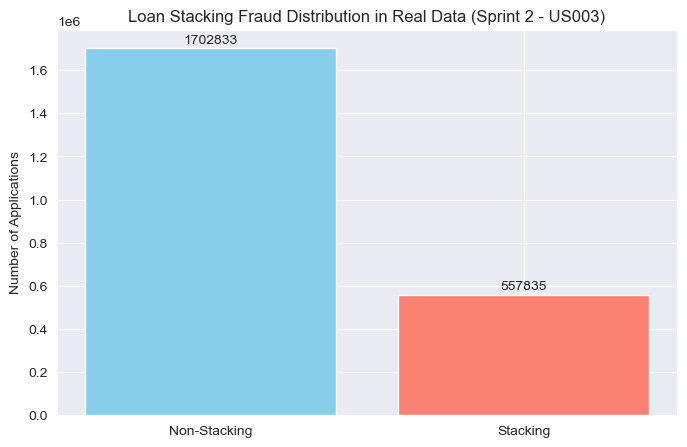


Preliminary Verification with Baseline Model (Sprint 2 - US003):
Accuracy of baseline model predictions vs. loan_stacking_fraud labels: 0.7925
Classification Report for loan stacking fraud detection:
              precision    recall  f1-score   support

Non-Stacking       0.99      0.73      0.84    340702
    Stacking       0.54      0.98      0.70    111432

    accuracy                           0.79    452134
   macro avg       0.77      0.86      0.77    452134
weighted avg       0.88      0.79      0.81    452134


Sprint 2 - US004: Generating Synthetic Fraud Data...

Synthetic Fraud Data Generation Results (Sprint 2 - US004):
Total Synthetic Samples Generated: 157812
- Loan Stacking Fraud: 71106 (45.06%)
- Geographical Fraud: 101804 (64.51%)
- DTI Fraud: 157812 (100.00%)
New Fields Included in Synthetic Data:
- revol_bal, revol_util, delinq_2yrs, inq_last_6mths, open_acc, pub_rec, total_acc, mort_acc, credit_age_years


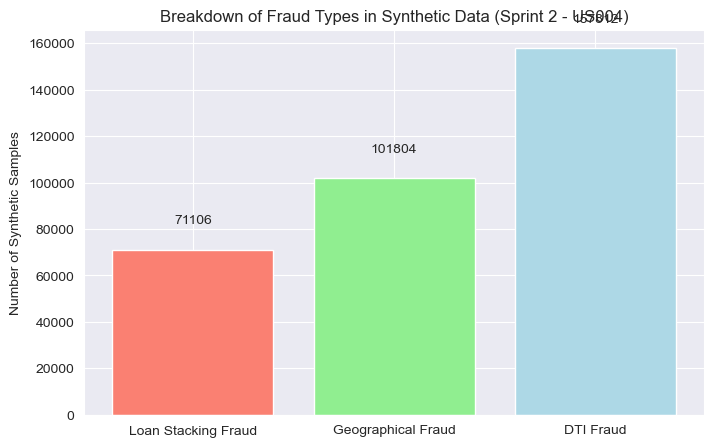


Sprint 3 - US005: Dataset Balance After Implementing Synthetic Fraud:

Dataset Balance After Implementing Synthetic Fraud:
Total Rows: 1966346
Fraud Cases (1): 983173 (50.00%)
Non-Fraud Cases (0): 983173 (50.00%)


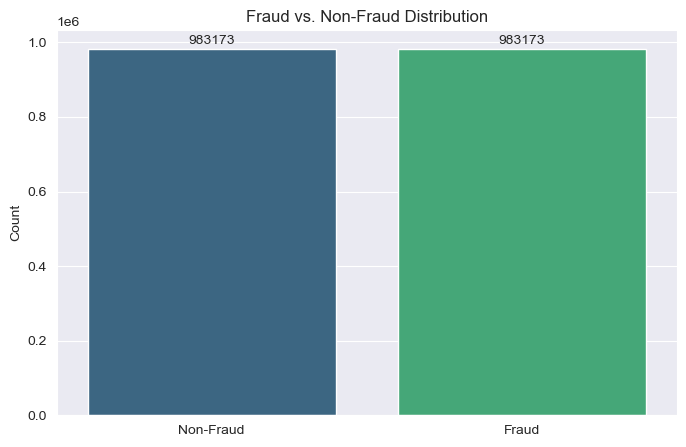

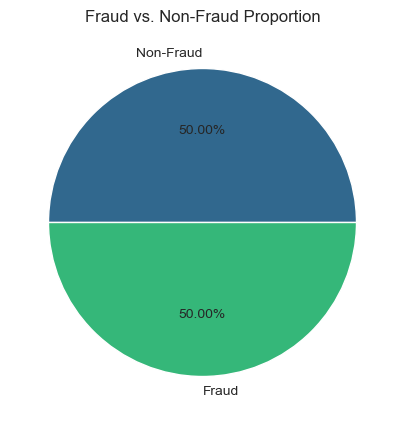


Sprint 3 - US006: Training Retrained Model with Combined Data...
Epoch [10/50], Loss: 0.6416, Fraud Cases: 38515.0
Epoch [20/50], Loss: 0.5449, Fraud Cases: 130391.0
Epoch [30/50], Loss: 0.4163, Fraud Cases: 142601.0
Epoch [40/50], Loss: 0.2790, Fraud Cases: 158387.0
Epoch [50/50], Loss: 0.1565, Fraud Cases: 184063.0

Sprint 3 - US006: Evaluating on real holdout set with threshold 0.5:
Classification Report (Threshold=0.5):
              precision    recall  f1-score   support

           0       0.82      0.96      0.88    245794
           1       0.94      0.75      0.83    206340

    accuracy                           0.86    452134
   macro avg       0.88      0.85      0.86    452134
weighted avg       0.88      0.86      0.86    452134

Accuracy: 0.8638
Precision-Recall AUC: 0.9024
Accuracy: 0.8638
Precision-Recall AUC: 0.9024
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.82      0.96      0.88    245794
       Fraud       0

In [99]:
# Cell 3: Define main() to Call the Modular Functions
def main():
    # Step 1: Load and prepare data
    data, zip_mapping, iso_forest = load_and_prepare_data('../data/final_data_cleaned.csv')
    
    # Step 2: Sprint 2 - US002 (Train baseline model)
    real_train, real_holdout, baseline_model, y_pred_baseline, reference_columns_baseline = sprint2_us002_train_baseline(data)
    
    # Step 3: Sprint 2 - US003 (Loan stacking fraud detection)
    sprint2_us003_loan_stacking(data, real_holdout, y_pred_baseline)
    
    # Step 4: Sprint 2 - US004 (Generate synthetic data)
    train_data = sprint2_us004_synthetic_data(real_train, zip_mapping)
    
    # Step 5: Sprint 3 - US005 (Check data balance)
    sprint3_us005_check_balance(train_data)
    
    # Step 6: Sprint 3 - US006 (Train retrained model)
    model, best_threshold, X_holdout_scaled, y_holdout = sprint3_us006_train_retrained(train_data, real_holdout, zip_mapping)
    
    # Step 7: Sprint 3 - US007 (Geographical fraud detection)
    sprint3_us007_geo_fraud(data, real_holdout, model, X_holdout_scaled, y_holdout)
    
    # Step 8: Save models
    save_models(model, best_threshold, iso_forest)

# Cell 4: Run main() once
print("Executing main() once...")
main()